In [5]:
# ============================================================
# Chai validation: ESM2 top-k vs random-k baseline
#
# Input:
#   Phase 4 handoff CSV from ESM2 scoring
#   Expected columns: candidate_id, phase3_rank, vh, vl, target_sequence
#
# Output:
#   1. Chai FASTA files
#   2. Chai run manifest
#   3. Chai output summary
#   4. Chai score summary
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

from pathlib import Path
import shutil
import subprocess
import glob
#import numpy as np
#import pandas as pd


# -----------------------------
# 0. Paths / config
# -----------------------------
PROJECT_DIR = Path("/content/drive/MyDrive/her2_project")

PHASE4_CSV = Path(
    "/content/drive/MyDrive/her2_project/rfantibody_her2/outputs/esm2_scores/her2_rfantibody_phase4_structure_validation_handoff.csv"
)

CHAI_DIR = PROJECT_DIR / "rfantibody_her2/outputs/chai_validation"
FASTA_DIR = CHAI_DIR / "fastas"
OUT_DIR = CHAI_DIR / "outputs"

FASTA_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_K = 5
RANDOM_K = 5
RANDOM_SEED = 42

Mounted at /content/drive


In [7]:
# -----------------------------
# 1. Load Phase 4 handoff
# -----------------------------
import numpy as np
import pandas as pd
df = pd.read_csv(PHASE4_CSV)

required = ["candidate_id", "phase3_rank", "phase3_composite_score", "vh", "vl", "target_sequence"]
missing = [c for c in required if c not in df.columns]
assert not missing, f"Missing columns: {missing}"

df = df.dropna(subset=["vh", "vl", "target_sequence"]).copy()
df = df.sort_values("phase3_rank").reset_index(drop=True)

print("Loaded candidates:", len(df))
df[["phase3_rank", "candidate_id", "phase3_composite_score"]].head()

Loaded candidates: 50


,phase3_rank,candidate_id,phase3_composite_score
0,1,samples_design_6_dldesign_2,1.651125
1,2,samples_design_6_dldesign_3,1.634978
2,3,samples_design_6_dldesign_4,1.227079
3,4,samples_design_6_dldesign_7,1.141807
4,5,samples_design_6_dldesign_5,0.876620


In [8]:
# -----------------------------
# 2. Select ESM2 top-k and random-k baseline
# -----------------------------
top_df = df.head(TOP_K).copy()
top_df["group"] = "esm2_top"

pool = df.iloc[TOP_K:].copy()
random_df = pool.sample(
    n=min(RANDOM_K, len(pool)),
    random_state=RANDOM_SEED,
).copy()
random_df["group"] = "random_baseline"

compare_df = pd.concat([top_df, random_df], ignore_index=True)

compare_df[[
    "group",
    "candidate_id",
    "phase3_rank",
    "phase3_composite_score",
]]

,group,candidate_id,phase3_rank,phase3_composite_score
0,esm2_top,samples_design_6_dldesign_2,1,1.651125
1,esm2_top,samples_design_6_dldesign_3,2,1.634978
2,esm2_top,samples_design_6_dldesign_4,3,1.227079
3,esm2_top,samples_design_6_dldesign_7,4,1.141807
4,esm2_top,samples_design_6_dldesign_5,5,0.876620
5,random_baseline,samples_design_2_dldesign_7,45,-0.380391
6,random_baseline,samples_design_3_dldesign_6,31,-0.085793
7,random_baseline,samples_design_1_dldesign_7,32,-0.090755
8,random_baseline,samples_design_3_dldesign_1,49,-0.616395
9,random_baseline,samples_design_0_dldesign_5,41,-0.222683


In [9]:
# -----------------------------
# 3. Write Chai FASTA files
#
# Chai input order:
#   HER2 target
#   VH
#   VL
# -----------------------------
def write_chai_fasta(row):
    cid = row["candidate_id"]
    group = row["group"]

    fasta_path = FASTA_DIR / f"{group}_{cid}.fasta"

    with open(fasta_path, "w") as f:
        f.write(f">protein|HER2\n{row['target_sequence']}\n")
        f.write(f">protein|VH\n{row['vh']}\n")
        f.write(f">protein|VL\n{row['vl']}\n")

    return str(fasta_path)


compare_df["chai_fasta"] = compare_df.apply(write_chai_fasta, axis=1)

MANIFEST_CSV = CHAI_DIR / "chai_validation_manifest.csv"
compare_df.to_csv(MANIFEST_CSV, index=False)

print("Saved manifest:", MANIFEST_CSV)
compare_df[["group", "candidate_id", "chai_fasta"]]

Saved manifest: /content/drive/MyDrive/her2_project/rfantibody_her2/outputs/chai_validation/chai_validation_manifest.csv


,group,candidate_id,chai_fasta
0,esm2_top,samples_design_6_dldesign_2,/content/drive/MyDrive/her2_project/rfantibody...
1,esm2_top,samples_design_6_dldesign_3,/content/drive/MyDrive/her2_project/rfantibody...
2,esm2_top,samples_design_6_dldesign_4,/content/drive/MyDrive/her2_project/rfantibody...
3,esm2_top,samples_design_6_dldesign_7,/content/drive/MyDrive/her2_project/rfantibody...
4,esm2_top,samples_design_6_dldesign_5,/content/drive/MyDrive/her2_project/rfantibody...
5,random_baseline,samples_design_2_dldesign_7,/content/drive/MyDrive/her2_project/rfantibody...
6,random_baseline,samples_design_3_dldesign_6,/content/drive/MyDrive/her2_project/rfantibody...
7,random_baseline,samples_design_1_dldesign_7,/content/drive/MyDrive/her2_project/rfantibody...
8,random_baseline,samples_design_3_dldesign_1,/content/drive/MyDrive/her2_project/rfantibody...
9,random_baseline,samples_design_0_dldesign_5,/content/drive/MyDrive/her2_project/rfantibody...


In [14]:
# ============================================================
# Dependency reset before running Chai
# Run this in a fresh runtime, then restart runtime once if needed
# ============================================================

!pip uninstall -y numpy pandas scipy scikit-learn chai_lab pandera

!pip install -q \
  "numpy==1.26.4" \
  "pandas==2.2.2" \
  "scipy==1.11.4" \
  "scikit-learn==1.4.2" \
  "biopython" \
  "matplotlib" \
  "chai_lab"

Found existing installation: numpy 2.0.2
Uninstalling numpy-2.0.2:
  Successfully uninstalled numpy-2.0.2
Found existing installation: pandas 2.2.2
Uninstalling pandas-2.2.2:
  Successfully uninstalled pandas-2.2.2
Found existing installation: scipy 1.16.3
Uninstalling scipy-1.16.3:
  Successfully uninstalled scipy-1.16.3
Found existing installation: scikit-learn 1.6.1
Uninstalling scikit-learn-1.6.1:
  Successfully uninstalled scikit-learn-1.6.1
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 kB 7.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 40.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 130.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 153.6 MB/s eta 0:00:00
   ━━━━━━━━━━

In [4]:
import numpy, pandas, scipy, sklearn
print("numpy", numpy.__version__)
print("pandas", pandas.__version__)
print("scipy", scipy.__version__)
print("sklearn", sklearn.__version__)

import chai_lab
print("chai_lab imported")

numpy 2.0.2
pandas 2.2.2
scipy 1.16.3
sklearn 1.6.1
chai_lab imported


In [14]:
!nvidia-smi

Mon May  4 17:43:56 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   31C    P0             45W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
!pip install -q chai_lab

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 401.2/401.2 kB 40.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.1/172.1 kB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 85.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 kB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 118.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 34.3/34.3 MB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 766.6/766.6 MB 1.6 MB/s eta 0:00

In [19]:
# -----------------------------
# 4. Optional: run Chai
#
# Skip this cell if you want to run Chai elsewhere.
# -----------------------------
import subprocess, shutil
from pathlib import Path

RUN_CHAI = True

if RUN_CHAI:
    for j, (_, row) in enumerate(compare_df.iterrows(), start=1):
        cid = row["candidate_id"]
        group = row["group"]

        fasta = str(Path(row["chai_fasta"]).resolve())
        out = OUT_DIR / f"{group}_{cid}"

        if out.exists():
            shutil.rmtree(out)
        out.mkdir(parents=True, exist_ok=True)

        cmd = ["chai-lab", "fold", fasta, str(out)]

        print(f"\n🚀 [{j}/{len(compare_df)}] Running Chai: {group} | {cid}")
        print("CMD:", " ".join(cmd))

        process = subprocess.Popen(
            cmd,
            stdout=subprocess.PIPE,
            stderr=subprocess.STDOUT,
            text=True,
            bufsize=1,
        )

        for line in process.stdout:
            print(line, end="")

        process.wait()

        if process.returncode != 0:
            print(f"\n❌ FAILED: {group} | {cid}")
            break
        else:
            print(f"\n✅ DONE: {group} | {cid}")


🚀 [1/10] Running Chai: esm2_top | samples_design_6_dldesign_2
CMD: chai-lab fold /content/drive/MyDrive/her2_project/rfantibody_her2/outputs/chai_validation/fastas/esm2_top_samples_design_6_dldesign_2.fasta /content/drive/MyDrive/her2_project/rfantibody_her2/outputs/chai_validation/outputs/esm2_top_samples_design_6_dldesign_2
/usr/local/lib/python3.12/dist-packages/pandera/_pandas_deprecated.py:154: FutureWarning: Importing pandas-specific classes and functions from the
top-level pandera module will be **removed in a future version of pandera**.
If you're using pandera to validate pandas objects, we highly recommend updating
your import:

```
# old import
import pandera as pa

# new import
import pandera.pandas as pa
```

If you're using pandera to validate objects from other compatible libraries
like pyspark or polars, see the supported libraries section of the documentation
for more information on how to import pandera:

https://pandera.readthedocs.io/en/stable/supported_libraries.h

In [20]:
# -----------------------------
# 5. Collect Chai outputs
# -----------------------------
rows = []

for _, row in compare_df.iterrows():
    cid = row["candidate_id"]
    group = row["group"]
    out = OUT_DIR / f"{group}_{cid}"

    cif_files = glob.glob(str(out / "**/*.cif"), recursive=True)
    pdb_files = glob.glob(str(out / "**/*.pdb"), recursive=True)
    npz_files = glob.glob(str(out / "**/*.npz"), recursive=True)
    json_files = glob.glob(str(out / "**/*.json"), recursive=True)

    rows.append({
        "group": group,
        "candidate_id": cid,
        "phase3_rank": row["phase3_rank"],
        "phase3_composite_score": row["phase3_composite_score"],
        "chai_output_dir": str(out),
        "n_cif": len(cif_files),
        "n_pdb": len(pdb_files),
        "n_npz": len(npz_files),
        "n_json": len(json_files),
        "structure_file": cif_files[0] if cif_files else (pdb_files[0] if pdb_files else ""),
        "score_file": npz_files[0] if npz_files else "",
    })

chai_summary = pd.DataFrame(rows)

SUMMARY_CSV = CHAI_DIR / "chai_output_summary.csv"
chai_summary.to_csv(SUMMARY_CSV, index=False)

print("Saved:", SUMMARY_CSV)
chai_summary

Saved: /content/drive/MyDrive/her2_project/rfantibody_her2/outputs/chai_validation/chai_output_summary.csv


,group,candidate_id,phase3_rank,phase3_composite_score,chai_output_dir,n_cif,n_pdb,n_npz,n_json,structure_file,score_file
0,esm2_top,samples_design_6_dldesign_2,1,1.651125,/content/drive/MyDrive/her2_project/rfantibody...,5,0,5,0,/content/drive/MyDrive/her2_project/rfantibody...,/content/drive/MyDrive/her2_project/rfantibody...
1,esm2_top,samples_design_6_dldesign_3,2,1.634978,/content/drive/MyDrive/her2_project/rfantibody...,5,0,5,0,/content/drive/MyDrive/her2_project/rfantibody...,/content/drive/MyDrive/her2_project/rfantibody...
2,esm2_top,samples_design_6_dldesign_4,3,1.227079,/content/drive/MyDrive/her2_project/rfantibody...,5,0,5,0,/content/drive/MyDrive/her2_project/rfantibody...,/content/drive/MyDrive/her2_project/rfantibody...
3,esm2_top,samples_design_6_dldesign_7,4,1.141807,/content/drive/MyDrive/her2_project/rfantibody...,5,0,5,0,/content/drive/MyDrive/her2_project/rfantibody...,/content/drive/MyDrive/her2_project/rfantibody...
4,esm2_top,samples_design_6_dldesign_5,5,0.876620,/content/drive/MyDrive/her2_project/rfantibody...,5,0,5,0,/content/drive/MyDrive/her2_project/rfantibody...,/content/drive/MyDrive/her2_project/rfantibody...
5,random_baseline,samples_design_2_dldesign_7,45,-0.380391,/content/drive/MyDrive/her2_project/rfantibody...,5,0,5,0,/content/drive/MyDrive/her2_project/rfantibody...,/content/drive/MyDrive/her2_project/rfantibody...
6,random_baseline,samples_design_3_dldesign_6,31,-0.085793,/content/drive/MyDrive/her2_project/rfantibody...,5,0,5,0,/content/drive/MyDrive/her2_project/rfantibody...,/content/drive/MyDrive/her2_project/rfantibody...
7,random_baseline,samples_design_1_dldesign_7,32,-0.090755,/content/drive/MyDrive/her2_project/rfantibody...,5,0,5,0,/content/drive/MyDrive/her2_project/rfantibody...,/content/drive/MyDrive/her2_project/rfantibody...
8,random_baseline,samples_design_3_dldesign_1,49,-0.616395,/content/drive/MyDrive/her2_project/rfantibody...,5,0,5,0,/content/drive/MyDrive/her2_project/rfantibody...,/content/drive/MyDrive/her2_project/rfantibody...
9,random_baseline,samples_design_0_dldesign_5,41,-0.222683,/content/drive/MyDrive/her2_project/rfantibody...,5,0,5,0,/content/drive/MyDrive/her2_project/rfantibody...,/content/drive/MyDrive/her2_project/rfantibody...


In [30]:
# -----------------------------
# 6. Extract Chai model scores from .npz + summarize by group
# -----------------------------
import numpy as np
import pandas as pd

def scalar_npz(data, key):
    if key not in data:
        return np.nan
    x = np.asarray(data[key])
    return float(x.reshape(-1)[0]) if x.size else np.nan

def bool_npz(data, key):
    if key not in data:
        return np.nan
    x = np.asarray(data[key])
    return bool(x.reshape(-1)[0]) if x.size else np.nan

def array_npz(data, key):
    if key not in data:
        return np.nan
    return np.asarray(data[key]).tolist()

score_rows = []

for _, row in chai_summary.iterrows():
    npz_file = row["score_file"]

    if not isinstance(npz_file, str) or not npz_file:
        continue

    data = np.load(npz_file, allow_pickle=True)

    score_rows.append({
        "group": row["group"],
        "candidate_id": row["candidate_id"],

        # Chai scalar metrics
        "aggregate_score": scalar_npz(data, "aggregate_score"),
        "ptm": scalar_npz(data, "ptm"),
        "iptm": scalar_npz(data, "iptm"),

        # clash metrics
        "has_inter_chain_clashes": bool_npz(data, "has_inter_chain_clashes"),
        "chain_chain_clashes": array_npz(data, "chain_chain_clashes"),
    })

chai_score_df = pd.DataFrame(score_rows)

SCORES_CSV = CHAI_DIR / "chai_scores.csv"
chai_score_df.to_csv(SCORES_CSV, index=False)

print("Saved:", SCORES_CSV)
display(chai_score_df)


# -----------------------------
# 6b. Group-level Chai summary
# -----------------------------
summary_rows = []

for group, g in chai_score_df.groupby("group"):
    summary_rows.append({
        "group": group,
        "n": len(g),

        # optional sequence/interface columns, only if present
        "mean_cdr": g["cdr_hotspot_contacts"].mean() if "cdr_hotspot_contacts" in g.columns else np.nan,
        "mean_interface": g["binder_score"].mean() if "binder_score" in g.columns else np.nan,
        "mean_clash": g["clashes"].mean() if "clashes" in g.columns else np.nan,

        # Chai metrics
        "mean_iptm": g["iptm"].mean(),
        "mean_ptm": g["ptm"].mean(),
        "mean_aggregate": g["aggregate_score"].mean(),

        # viability
        "inter_chain_clash_rate": g["has_inter_chain_clashes"].mean(),
        "viable_frac": (~g["has_inter_chain_clashes"].fillna(True)).mean(),
    })

chai_group_summary = pd.DataFrame(summary_rows)
chai_group_summary["viable_%"] = 100 * chai_group_summary["viable_frac"]

SUMMARY_CSV = CHAI_DIR / "chai_group_summary.csv"
chai_group_summary.to_csv(SUMMARY_CSV, index=False)

print("Saved:", SUMMARY_CSV)
display(chai_group_summary)

Saved: /content/drive/MyDrive/her2_project/rfantibody_her2/outputs/chai_validation/chai_scores.csv


,group,candidate_id,aggregate_score,ptm,iptm,has_inter_chain_clashes,chain_chain_clashes
0,esm2_top,samples_design_6_dldesign_2,0.618538,0.719317,0.593344,False,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0]]]"
1,esm2_top,samples_design_6_dldesign_3,0.626729,0.729442,0.601051,False,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0]]]"
2,esm2_top,samples_design_6_dldesign_4,0.648959,0.742237,0.625639,False,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0]]]"
3,esm2_top,samples_design_6_dldesign_7,0.635508,0.732297,0.611310,False,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0]]]"
4,esm2_top,samples_design_6_dldesign_5,0.644859,0.740845,0.620862,False,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0]]]"
5,random_baseline,samples_design_2_dldesign_7,0.626169,0.725059,0.601446,False,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0]]]"
6,random_baseline,samples_design_3_dldesign_6,0.624029,0.721874,0.599568,False,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0]]]"
7,random_baseline,samples_design_1_dldesign_7,0.609444,0.714984,0.583059,False,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0]]]"
8,random_baseline,samples_design_3_dldesign_1,0.669101,0.751673,0.648458,False,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0]]]"
9,random_baseline,samples_design_0_dldesign_5,0.595933,0.696795,0.570717,False,"[[[0, 0, 0], [0, 0, 0], [0, 0, 0]]]"


Saved: /content/drive/MyDrive/her2_project/rfantibody_her2/outputs/chai_validation/chai_group_summary.csv


,group,n,mean_cdr,mean_interface,mean_clash,mean_iptm,mean_ptm,mean_aggregate,inter_chain_clash_rate,viable_frac,viable_%
0,esm2_top,5,NaN,NaN,NaN,0.610441,0.732828,0.634919,0.0,1.0,100.0
1,random_baseline,5,NaN,NaN,NaN,0.600650,0.722077,0.624935,0.0,1.0,100.0


In [31]:
import numpy as np

npz_file = chai_summary.iloc[0]["score_file"]

data = np.load(npz_file)

print("Keys in npz:")
print(data.files)

Keys in npz:
['aggregate_score', 'ptm', 'iptm', 'per_chain_ptm', 'per_chain_pair_iptm', 'has_inter_chain_clashes', 'chain_chain_clashes']


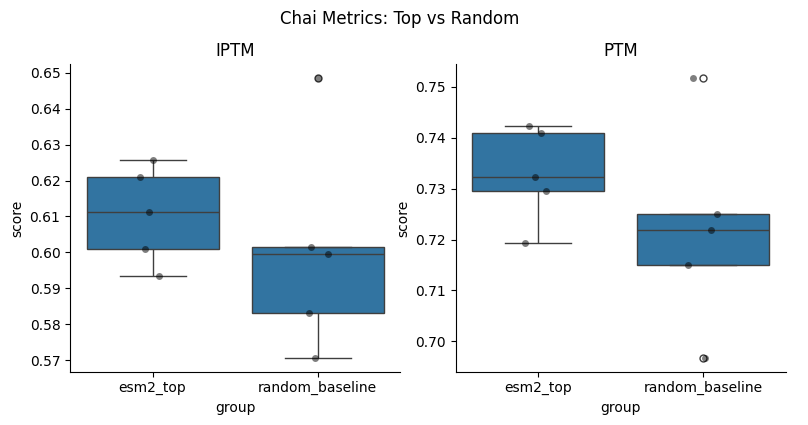

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

df = chai_score_df.copy()

# keep only available metrics
metrics = ["iptm", "ptm"]   # add others if you have them

df_long = df.melt(
    id_vars="group",
    value_vars=metrics,
    var_name="metric",
    value_name="score"
)

g = sns.catplot(
    data=df_long,
    x="group",
    y="score",
    col="metric",
    kind="box",
    sharey=False,
    height=4,
    aspect=1
)

# overlay points
for ax, m in zip(g.axes.flat, metrics):
    sns.stripplot(
        data=df_long[df_long["metric"] == m],
        x="group",
        y="score",
        color="black",
        alpha=0.5,
        ax=ax
    )
    ax.set_title(m.upper())

plt.suptitle("Chai Metrics: Top vs Random", y=1.05)
plt.show()

In [33]:
!pip install -q py3Dmol

In [37]:
import py3Dmol
from pathlib import Path

from pathlib import Path

OUT_DIR = Path("/content/drive/MyDrive/her2_project/rfantibody_her2/outputs/chai_validation/outputs")

esm2 = sorted(OUT_DIR.glob("esm2_top*/**/*.cif"))
random = sorted(OUT_DIR.glob("random_baseline*/**/*.cif"))

print("ESM2 example:", esm2[0])
print("Random example:", random[0])

# choose one ESM2 and one random structure
esm2_path = esm2[0]
random_path = random[0]

def add_complex(view, path, viewer, title):
    path = Path(path)
    with open(path) as f:
        data = f.read()

    view.addModel(data, "cif", viewer=viewer)

    # A = HER2, B = VH, C = VL
    view.setStyle({"chain": "A"}, {"cartoon": {"color": "lightgray"}}, viewer=viewer)
    view.setStyle({"chain": "B"}, {"cartoon": {"color": "cyan"}}, viewer=viewer)
    view.setStyle({"chain": "C"}, {"cartoon": {"color": "blue"}}, viewer=viewer)

    # HER2 semi-transparent surface
    view.addSurface(
        py3Dmol.VDW,
        {"opacity": 0.28, "color": "orange"},
        {"chain": "A"},
        viewer=viewer,
    )

    # Approximate CDR loops
    cdr_ranges = [
        {"chain": "B", "resi": "27-38"},
        {"chain": "B", "resi": "56-65"},
        {"chain": "B", "resi": "105-117"},
        {"chain": "C", "resi": "27-38"},
        {"chain": "C", "resi": "56-65"},
        {"chain": "C", "resi": "105-117"},
    ]

    for sel in cdr_ranges:
        view.addStyle(sel, {"cartoon": {"color": "yellow"}}, viewer=viewer)
        view.addStyle(sel, {"stick": {"color": "yellow", "radius": 0.18}}, viewer=viewer)

    # Antibody interface residues within 4 Å of HER2
    interface_sel = {
        "and": [
            {"or": [{"chain": "B"}, {"chain": "C"}]},
            {"within": {"distance": 4.0, "sel": {"chain": "A"}}}
        ]
    }

    view.addStyle(
        interface_sel,
        {"stick": {"color": "red", "radius": 0.22}},
        viewer=viewer,
    )

    # Labels
    view.addLabel(
        title,
        {
            "position": {"x": 0, "y": 0, "z": 0},
            "backgroundColor": "white",
            "fontColor": "black",
            "fontSize": 18,
            "showBackground": True,
        },
        viewer=viewer,
    )

    view.zoomTo({"or": [{"chain": "A"}, {"chain": "B"}, {"chain": "C"}]}, viewer=viewer)


view = py3Dmol.view(width=1100, height=520, viewergrid=(1, 2))

add_complex(view, esm2_path, viewer=(0, 0), title="ESM2-top")
add_complex(view, random_path, viewer=(0, 1), title="Random baseline")

view.show()

ESM2 example: /content/drive/MyDrive/her2_project/rfantibody_her2/outputs/chai_validation/outputs/esm2_top_samples_design_0_dldesign_2/pred.model_idx_0.cif
Random example: /content/drive/MyDrive/her2_project/rfantibody_her2/outputs/chai_validation/outputs/random_baseline_samples_design_0_dldesign_5/pred.model_idx_0.cif


3Dmol.js failed to load for some reason. Please check your browser console for error messages.